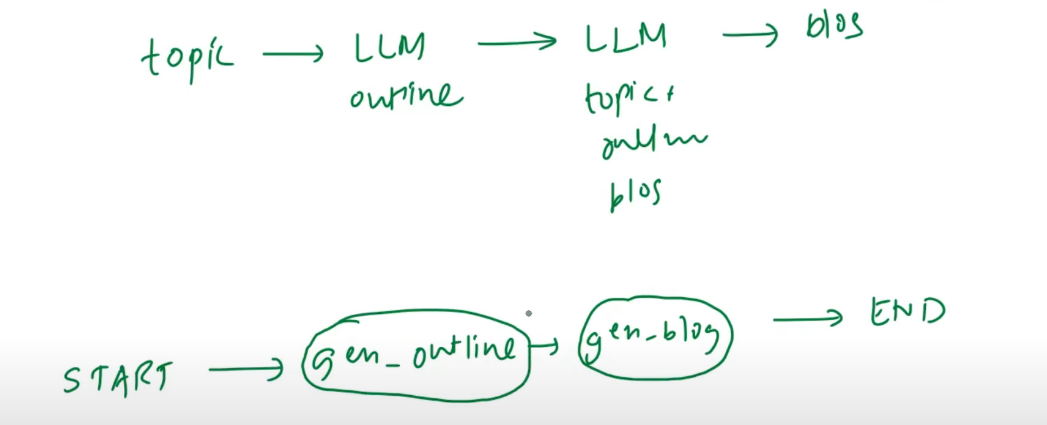

In [1]:
from langgraph.graph import StateGraph
from typing import TypedDict
from langgraph.graph import StateGraph,MessagesState,START,END

from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [ ]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state 

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)


graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)


workflow = graph.compile()

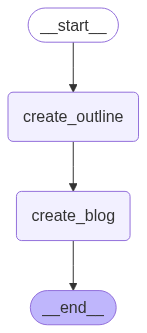

In [8]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [9]:
initial_state = {'title':'Historical evaliation of Generative AI'}

final_state = workflow.invoke(initial_state)

In [10]:
print(final_state['outline'])

I. Introduction
    A. Brief overview of generative AI
    B. Importance of historical evaluation in understanding the development of AI technology

II. Early developments in generative AI
    A. Introduction of neural networks and deep learning
    B. Historical precursors to generative AI, such as Markov models
    C. Breakthroughs in generative models, such as Generative Adversarial Networks (GANs)

III. Applications of generative AI throughout history
    A. Creativity and art generation
    B. Image and video synthesis
    C. Text generation and natural language processing
    D. Advancements in healthcare, finance, and other industries

IV. Challenges and limitations of generative AI
    A. Ethical concerns surrounding the use of AI-generated content
    B. Bias and lack of diversity in training data
    C. Potential for misuse and misinformation

V. Historical evaluation of generative AI in popular culture
    A. Influence of AI-generated media on art and entertainment
    B. De

In [11]:
print(final_state['content'])

Generative artificial intelligence (AI) has made significant advancements in recent years, revolutionizing the way we create and interact with digital content. From creating art and music to generating realistic images and videos, generative AI has had a profound impact on various industries and applications. However, in order to fully understand the development and implications of this technology, it is essential to conduct a historical evaluation of generative AI.

The early developments in generative AI can be traced back to the introduction of neural networks and deep learning algorithms. These technologies laid the foundation for the creation of generative models, which aim to produce new data that is similar to the training data they were given. Historical precursors to generative AI, such as Markov models, also played a key role in the development of this technology. Breakthroughs in generative models, such as the introduction of Generative Adversarial Networks (GANs), further a

###  Workflow2 - with Evaluator

In [12]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    rating: int

In [13]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state 

In [14]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [15]:
def get_rating(state: BlogState) -> BlogState:
    title = state['title']
    outline= state['outline']
    content = state['content']

    prompt = f'Based on the title provided - {title} and the generated outline -\n {outline} \
        as well as generated blog -\n {content}. \
            evaluate the quality and return me integer score on scale of 1 to 100. '
    
    content = model.invoke(prompt).content  

    state['rating'] = content

    return state

In [16]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('get_rating',get_rating)


graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','get_rating')
graph.add_edge('get_rating', END)


workflow2 = graph.compile()

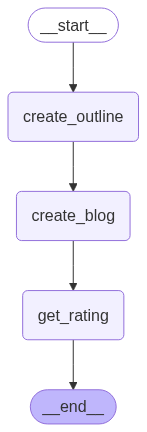

In [17]:
from IPython.display import Image, display
display(Image(workflow2.get_graph().draw_mermaid_png()))

In [19]:
initial_state = {'title':'Historical evaliation of Generative AI'}

final_state = workflow2.invoke(initial_state)

In [ ]:
print(final_state['outline'])

I. Introduction
    A. Explanation of Generative AI and its significance in the field of artificial intelligence
    B. Purpose of the blog - to delve into the historical development and evaluation of Generative AI

II. Overview of AI advancements leading to Generative AI
    A. Brief history of artificial intelligence research
    B. Introduction of Generative Adversarial Networks (GANs) and other key technologies
    C. Evolution of Generative AI over the years

III. Historical milestones in Generative AI development
    A. Early experiments and breakthroughs in Generative AI
    B. Key research papers and projects that have shaped the field
    C. Impact of Generative AI on other areas of AI research

IV. Applications and use cases of Generative AI
    A. Creative applications such as art generation, music composition, etc.
    B. Practical applications in industries like healthcare, finance, and more
    C. Ethical considerations and challenges in the use of Generative AI

V. Evalu

In [21]:
print(final_state['content'])

Generative Artificial Intelligence (AI) has gained significant attention in recent years for its ability to create new data or information based on patterns from existing data. This technology has not only revolutionized various industries but also opened up new possibilities in the field of AI. In this blog, we will delve into the historical evaluation of Generative AI, exploring its evolution, milestones, applications, and effectiveness.

I. Introduction

A. Generative AI refers to AI systems that are capable of creating new data, images, text, or other content based on patterns and trends in existing data. This technology is significant in the field of AI as it allows machines to generate information that can be used for various purposes such as art generation, music composition, and more.

B. The purpose of this blog is to explore the historical development of Generative AI and evaluate its effectiveness in comparison to other AI techniques. By understanding the evolution of Genera

In [22]:
print(final_state['rating'])

Based on the generated outline, the quality of the content appears to be comprehensive and well-structured. The outline covers all the key aspects of a historical evaluation of Generative AI, including its introduction, overview of advancements, historical milestones, applications, evaluation of effectiveness, and conclusion. The outline also includes relevant information, examples, and considerations in each section.

I would rate this outline a score of 90 out of 100 for its depth, coverage, and organization of the content related to Generative AI.
